# Cold Start Strategies – Impact on Training Performance

## Purpose
This notebook evaluates how different cold start strategies affect downstream
training performance **before any active learning querying is performed**.

We isolate the effect of the initial labeled set by:
- fixing the number of labeled samples,
- disabling active learning cycles,
- using the same model, optimizer, and training procedure.

## Key Question
Does a better cold start (in terms of diversity or u


In [5]:
from pathlib import Path
import sys
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path("..").resolve()))

from src.active_learning import ActiveLearningSystem
from config.config import ActiveLearningConfig
from src.utils import save_results_json

## Experimental Setup

All experiments in this notebook share the same configuration:

- Same dataset and validation split
- Same model architecture (U-Net)
- Same optimizer and hyperparameters
- Same number of training epochs
- Same random seed

The only difference between experiments is **which samples are selected
as the initial labeled set** by the cold start strategy.


## Training Protocol

For each cold start strategy:

1. Initialize an `ActiveLearningSystem`
2. Override the labeled pool using the selected indices
3. Disable active learning cycles (no querying)
4. Train the model for a fixed number of epochs
5. Record validation metrics at each epoch

This ensures that performance differences are attributable **only**
to the quality of the initial labeled set.


In [12]:
ls "results/"

checkpoints/                               logs/
cold_start_selections_DeepCrack_0.15.json  random_uncertainty.json
cold_start_selections.json


In [13]:
# Load cold start selections generated in the previous notebook

with open("results/cold_start_selections_DeepCrack_0.15.json", "r") as f:
    cold_start_selections = json.load(f)

list(cold_start_selections.keys())

['random',
 'simple_diversity',
 'diversity',
 'entropy_based_uncertainty',
 'weak_supervision',
 'self_supervised']

In [14]:
BASE_CONFIG_PATH = "../experiments/configs/example_segmentation.yaml"
EPOCHS = 15
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
results = {}

for strategy, labeled_indices in cold_start_selections.items():
    print(f"\n{'='*60}")
    print(f"Training with cold start strategy: {strategy}")
    print(f"{'='*60}")

    # Load configuration
    config = ActiveLearningConfig.from_yaml(BASE_CONFIG_PATH)
    config.al_cycles = 0                 # Disable querying
    config.cold_start_strategy = strategy
    config.use_wandb = False
    config.seed = SEED

    # Initialize system (skip internal cold start)
    al_system = ActiveLearningSystem(config, skip_cold_start=True)

    # Override labeled pool
    al_system.set_labeled_indices(labeled_indices)

    # Train only
    al_system.train(epochs=EPOCHS)

    # Store results
    results[strategy] = {
        "history": al_system.history,
        "final_dice": al_system.history["val_dice"][-1],
        "final_iou": al_system.history["val_iou"][-1],
        "num_labeled": len(labeled_indices),
    }



Training with cold start strategy: random
[DeepCrack] 300 samples loaded for split='train'
[DeepCrack] 237 samples loaded for split='val'


2026-01-30 17:35:42,155 - al_experiment - INFO - Manually set labeled pool: 45 labeled, 255 unlabeled
INFO:al_experiment:Manually set labeled pool: 45 labeled, 255 unlabeled


Active Learning System initialized with:
  Device: cuda
  Cold Start Strategy: random
  Query Strategy: uncertainty

Training cycle 0 with 45 samples


2026-01-30 17:35:52,728 - al_experiment - INFO - Epoch 1 | Loss: 0.4378 | Dice: 0.0783 | IoU: 0.0416 | Labeled: 45
INFO:al_experiment:Epoch 1 | Loss: 0.4378 | Dice: 0.0783 | IoU: 0.0416 | Labeled: 45
2026-01-30 17:36:00,814 - al_experiment - INFO - Epoch 2 | Loss: 0.2311 | Dice: 0.0286 | IoU: 0.0158 | Labeled: 45
INFO:al_experiment:Epoch 2 | Loss: 0.2311 | Dice: 0.0286 | IoU: 0.0158 | Labeled: 45
2026-01-30 17:36:07,884 - al_experiment - INFO - Epoch 3 | Loss: 0.1663 | Dice: 0.0000 | IoU: 0.0000 | Labeled: 45
INFO:al_experiment:Epoch 3 | Loss: 0.1663 | Dice: 0.0000 | IoU: 0.0000 | Labeled: 45
2026-01-30 17:36:14,897 - al_experiment - INFO - Epoch 4 | Loss: 0.1225 | Dice: 0.0000 | IoU: 0.0000 | Labeled: 45
INFO:al_experiment:Epoch 4 | Loss: 0.1225 | Dice: 0.0000 | IoU: 0.0000 | Labeled: 45
2026-01-30 17:36:21,971 - al_experiment - INFO - Epoch 5 | Loss: 0.0984 | Dice: 0.0016 | IoU: 0.0008 | Labeled: 45
INFO:al_experiment:Epoch 5 | Loss: 0.0984 | Dice: 0.0016 | IoU: 0.0008 | Labeled: 45



Training with cold start strategy: simple_diversity
[DeepCrack] 300 samples loaded for split='train'
[DeepCrack] 237 samples loaded for split='val'


...

2026-01-30 17:43:37,686 - al_experiment - INFO - Epoch 1 | Loss: 0.6694 | Dice: 0.1019 | IoU: 0.0551 | Labeled: 45
INFO:al_experiment:Epoch 1 | Loss: 0.6694 | Dice: 0.1019 | IoU: 0.0551 | Labeled: 45
2026-01-30 17:43:45,678 - al_experiment - INFO - Epoch 2 | Loss: 0.3310 | Dice: 0.0785 | IoU: 0.0419 | Labeled: 45
INFO:al_experiment:Epoch 2 | Loss: 0.3310 | Dice: 0.0785 | IoU: 0.0419 | Labeled: 45
2026-01-30 17:43:52,771 - al_experiment - INFO - Epoch 3 | Loss: 0.2615 | Dice: 0.0075 | IoU: 0.0041 | Labeled: 45
INFO:al_experiment:Epoch 3 | Loss: 0.2615 | Dice: 0.0075 | IoU: 0.0041 | Labeled: 45
2026-01-30 17:43:59,848 - al_experiment - INFO - Epoch 4 | Loss: 0.2526 | Dice: 0.0421 | IoU: 0.0255 | Labeled: 45
INFO:al_experiment:Epoch 4 | Loss: 0.2526 | Dice: 0.0421 | IoU: 0.0255 | Labeled: 45
2026-01-30 17:44:06,924 - al_experiment - INFO - Epoch 5 | Loss: 0.1736 | Dice: 0.0245 | IoU: 0.0143 | Labeled: 45
INFO:al_experiment:Epoch 5 | Loss: 0.1736 | Dice: 0.0245 | IoU: 0.0143 | Labeled: 45



Training with cold start strategy: self_supervised
[DeepCrack] 300 samples loaded for split='train'
[DeepCrack] 237 samples loaded for split='val'


2026-01-30 17:45:28,231 - al_experiment - INFO - Manually set labeled pool: 45 labeled, 255 unlabeled
INFO:al_experiment:Manually set labeled pool: 45 labeled, 255 unlabeled


Active Learning System initialized with:
  Device: cuda
  Cold Start Strategy: self_supervised
  Query Strategy: uncertainty

Training cycle 0 with 45 samples


2026-01-30 17:45:36,637 - al_experiment - INFO - Epoch 1 | Loss: 0.5486 | Dice: 0.0814 | IoU: 0.0436 | Labeled: 45
INFO:al_experiment:Epoch 1 | Loss: 0.5486 | Dice: 0.0814 | IoU: 0.0436 | Labeled: 45
2026-01-30 17:45:44,735 - al_experiment - INFO - Epoch 2 | Loss: 0.2983 | Dice: 0.1831 | IoU: 0.1268 | Labeled: 45
INFO:al_experiment:Epoch 2 | Loss: 0.2983 | Dice: 0.1831 | IoU: 0.1268 | Labeled: 45
2026-01-30 17:45:52,683 - al_experiment - INFO - Epoch 3 | Loss: 0.2114 | Dice: 0.0457 | IoU: 0.0267 | Labeled: 45
INFO:al_experiment:Epoch 3 | Loss: 0.2114 | Dice: 0.0457 | IoU: 0.0267 | Labeled: 45
2026-01-30 17:45:59,735 - al_experiment - INFO - Epoch 4 | Loss: 0.1599 | Dice: 0.0038 | IoU: 0.0020 | Labeled: 45
INFO:al_experiment:Epoch 4 | Loss: 0.1599 | Dice: 0.0038 | IoU: 0.0020 | Labeled: 45
2026-01-30 17:46:06,789 - al_experiment - INFO - Epoch 5 | Loss: 0.1316 | Dice: 0.0000 | IoU: 0.0000 | Labeled: 45
INFO:al_experiment:Epoch 5 | Loss: 0.1316 | Dice: 0.0000 | IoU: 0.0000 | Labeled: 45


## Final Performance Comparison

We compare cold start strategies using:
- Final Dice score
- Final mean IoU
- Number of labeled samples (fixed)

Higher Dice and IoU indicate better segmentation performance.

In [16]:
summary = []

for strategy, res in results.items():
    summary.append({
        "strategy": strategy,
        "final_dice": res["final_dice"],
        "final_iou": res["final_iou"],
        "num_labeled": res["num_labeled"],
    })

df_summary = pd.DataFrame(summary).sort_values("final_dice", ascending=False)
df_summary

,strategy,final_dice,final_iou,num_labeled
1,simple_diversity,0.653068,0.539891,45
5,self_supervised,0.544056,0.423785,45
3,entropy_based_uncertainty,0.535168,0.425993,45
0,random,0.531522,0.413702,45
2,diversity,0.497168,0.381910,45
4,weak_supervision,0.435357,0.325069,45


## Learning Curves

Training dynamics provide insight into:
- convergence speed,
- stability of optimization,
- usefulness of the initial labeled set.

Faster convergence and higher plateaus indicate a more effective cold start.

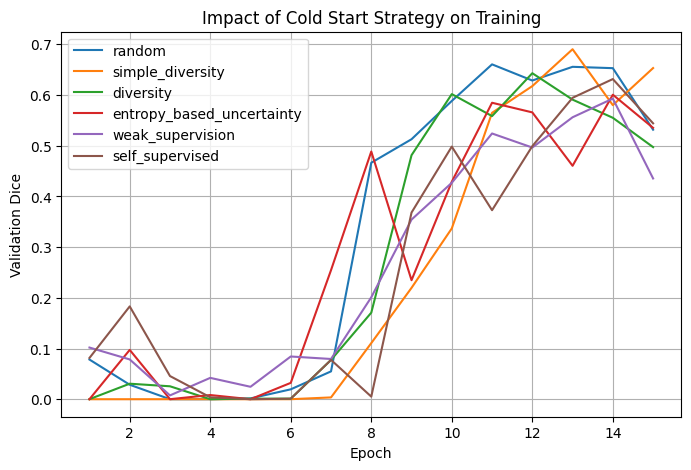

In [17]:
plt.figure(figsize=(8, 5))

for strategy, res in results.items():
    dice_curve = res["history"]["val_dice"]
    plt.plot(range(1, len(dice_curve) + 1), dice_curve, label=strategy)

plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("Impact of Cold Start Strategy on Training")
plt.grid(True)
plt.legend()
plt.show()

## Interpretation

This experiment allows us to identify which cold start strategies:

- lead to faster performance gains,
- reach higher final accuracy,
- provide a stable optimization trajectory.

The best-performing strategy will be used as the default cold start
configuration in the full active learning experiments (Notebook 04).


In [19]:
for strategy, res in results.items():
    out = {
        "experiment_type": "cold_start_training",
        "dataset": "DeepCrack",
        "strategy": strategy,
        "seed": SEED,
        "num_labeled": res["num_labeled"],
        "metrics": {
            "dice": {
                "history": res["history"]["val_dice"],
                "final": res["final_dice"],
                "best": max(res["history"]["val_dice"]),
            },
            "iou": {
                "history": res["history"]["val_iou"],
                "final": res["final_iou"],
                "best": max(res["history"]["val_iou"]),
            }
        }
    }

    save_results_json(
        results=out,
        experiment_name=f"cold_start_training_{strategy}_DeepCrack_0.15",
        results_dir="../results"
    )